In [2]:
from pathlib import Path 

import cv2
import IPython
import pandas as pd

In [3]:
def show_image(image):
    _, ret = cv2.imencode('.jpg', image)
    i = IPython.display.Image(data=ret)
    IPython.display.display(i)

In [4]:
def show_by_id(id):
    faces = pd.read_csv('../data/faces.csv', index_col=0)
    fp = Path('../test_images').joinpath(faces.iloc[id]['name'])
    img = cv2.imread(str(fp))
    print(fp.name)
    show_image(img)

In [5]:
def show_correct_by_id(id, df):
    temp = df[(df['id'] == id) & (df['x1'].notna())]
    return temp['detector']

In [36]:
def show_by_name(name):
    fp = Path('../test_images').joinpath(name)
    img = cv2.imread(str(fp))
    show_image(img)

In [6]:
faces = pd.read_csv('../data/faces.csv', index_col=0)
faces.head()

,name,img_height,img_width,x1,y1,x2,y2,width,height,area,pct_of_frame,face_num
0,Billions.S01E02.1080p.BluRay.x265-RARBG_40128.png,1080,1920,323,5,919,731,596,726,432696,0.208669,0
1,Billions.S01E09.1080p.BluRay.x265-RARBG_52704.png,1080,1920,262,42,614,507,352,465,163680,0.078935,0
2,Billions.S01E10.1080p.BluRay.x265-RARBG_51504.png,1080,1920,484,389,671,617,187,228,42636,0.020561,0
3,Billions.S01E10.1080p.BluRay.x265-RARBG_51504.png,1080,1920,1003,42,1195,261,192,219,42048,0.020278,1
4,Billions.S01E12.1080p.BluRay.x265-RARBG_78336.png,1080,1920,1121,66,1662,824,541,758,410078,0.197761,0


In [18]:
dlib_df = pd.read_csv('../data/test_results/dlib.csv', index_col=0)
dlib_df.head()

,x1,y1,x2,y2,width,height,area,confidence,face_num,img_width,img_height,pct_of_frame,id,name
0,530,251,938,659,408,408,166464,1.156534,0,1920,1080,0.080278,0,Billions.S01E02.1080p.BluRay.x265-RARBG_40128.png
1,239,181,522,464,283,283,80089,1.043341,0,1920,1080,0.038623,1,Billions.S01E09.1080p.BluRay.x265-RARBG_52704.png
2,546,450,683,586,137,136,18632,0.667519,0,1920,1080,0.008985,2,Billions.S01E10.1080p.BluRay.x265-RARBG_51504.png
3,996,109,1110,223,114,114,12996,0.637119,1,1920,1080,0.006267,2,Billions.S01E10.1080p.BluRay.x265-RARBG_51504.png
4,546,450,683,586,137,136,18632,0.667519,0,1920,1080,0.008985,3,Billions.S01E10.1080p.BluRay.x265-RARBG_51504.png


In [33]:
retina_df = pd.read_csv('../data/test_results/retina.csv', index_col=0)
retina_df = retina_df.groupby(['name', 'face_num']).max()
retina_df = retina_df.reset_index()
retina_df.head()

,name,face_num,x1,y1,x2,y2,width,height,area,confidence,img_width,img_height,pct_of_frame,id
0,Billions.S01E02.1080p.BluRay.x265-RARBG_40128.png,0,534,190,926,712,392,522,204624,0.999803,1920,1080,0.098681,0
1,Billions.S01E09.1080p.BluRay.x265-RARBG_52704.png,0,276,104,528,491,252,387,97524,0.999671,1920,1080,0.047031,1
2,Billions.S01E10.1080p.BluRay.x265-RARBG_51504.png,0,1002,81,1107,262,105,181,19005,0.999594,1920,1080,0.009165,3
3,Billions.S01E10.1080p.BluRay.x265-RARBG_51504.png,1,543,411,668,598,125,187,23375,0.999471,1920,1080,0.011273,3
4,Billions.S01E10.1080p.BluRay.x265-RARBG_51504.png,2,660,276,676,296,16,20,320,0.965943,1920,1080,0.000154,3


In [34]:
r = retina_df[['name', 'id']].groupby('name').count().rename({'id': 'retina'}, axis=1)
d = dlib_df[['name', 'id']].groupby('name').count().rename({'id': 'dlib'}, axis=1)
cnt_df = r.merge(d,
                 how='outer',
                 left_index=True,
                 right_index=True)
cnt_df

,retina,dlib
name,,
Billions.S01E02.1080p.BluRay.x265-RARBG_40128.png,1.0,1.0
Billions.S01E09.1080p.BluRay.x265-RARBG_52704.png,1.0,1.0
Billions.S01E10.1080p.BluRay.x265-RARBG_51504.png,3.0,4.0
Billions.S01E12.1080p.BluRay.x265-RARBG_78336.png,1.0,1.0
Billions.S02E01.1080p.BluRay.x265-RARBG_32328.png,1.0,1.0
...,...,...
Will.&.Grace.S11E17.New.Crib.1080p.Web.h264-JBee_28008.png,1.0,1.0
fargo.s05e02.2160p.web.h265-successfulcrab-sample_0336.png,1.0,NaN
fargo.s05e04.2160p.web.h265-successfulcrab_51600.png,1.0,1.0


In [35]:
diff = cnt_df[cnt_df['dlib'] != cnt_df['retina']]
diff

,retina,dlib
name,,
Billions.S01E10.1080p.BluRay.x265-RARBG_51504.png,3.0,4.0
Billions.S04E02.1080p.WEBRip.x265-RARBG_52416.png,1.0,NaN
Billions.S04E06.1080p.WEBRip.x265-RARBG_01344.png,2.0,4.0
Billions.S06E10.1080p.WEBRip.x265-RARBG_73680.png,3.0,5.0
Carnivale.S02E04.1080p.WEBRip.10Bit.EAC3.H265-d3g_20880.png,3.0,NaN
...,...,...
Will.&.Grace.S11E08.Lies.&.Whispers.1080p.Web.h264-JBee_00168.png,4.0,2.0
Will.&.Grace.S11E14.The.Favourite.1080p.Web.h264-JBee_25464.png,3.0,9.0
fargo.s05e02.2160p.web.h265-successfulcrab-sample_0336.png,1.0,NaN


In [48]:
missing = diff[diff['dlib'].isna()]
m = missing.index.to_list()
print(len(m))
m

121


['Billions.S04E02.1080p.WEBRip.x265-RARBG_52416.png',
 'Carnivale.S02E04.1080p.WEBRip.10Bit.EAC3.H265-d3g_20880.png',
 'Carnivale.S02E04.1080p.WEBRip.10Bit.EAC3.H265-d3g_32664.png',
 'Carnivale.S02E11.1080p.WEBRip.10Bit.EAC3.H265-d3g_49632.png',
 'Cheers.S02E01.1080p.BluRay.x265-RARBG_26040.png',
 'Cheers.S05E13.1080p.BluRay.x265-RARBG_19392.png',
 'Cheers.S06E09.1080p.BluRay.x265-RARBG_05688.png',
 'Cheers.S06E09.1080p.BluRay.x265-RARBG_26112.png',
 'Cheers.S09E05.1080p.BluRay.x265-RARBG_23376.png',
 'Cheers.S11E21.1080p.BluRay.x265-RARBG_22272.png',
 'For.All.Mankind.S01E03.1080p.WEBRip.x265-RARBG_51744.png',
 'Frasier.S01E02.Space.Quest.1080p.BluRay.10Bit.Dts-HDMa2.0.HEVC-d3g_15360.png',
 'Frasier.S02E05.Dukes.We.Hardly.Knew.Ye.1080p.BluRay.10Bit.Dts-HDMa2.0.HEVC-d3g_31704.png',
 'Frasier.S03E07.The.Adventures.of.Bad.Boy.and.Dirty.Girl.2.1080p.BluRay.10Bit.Dts-HDMa2.0.HEVC-d3g_28392.png',
 'Frasier.S03E21.Where.Theres.Smoke.Theres.Fired.1080p.BluRay.10Bit.Dts-HDMa2.0.HEVC-d3g_25488.

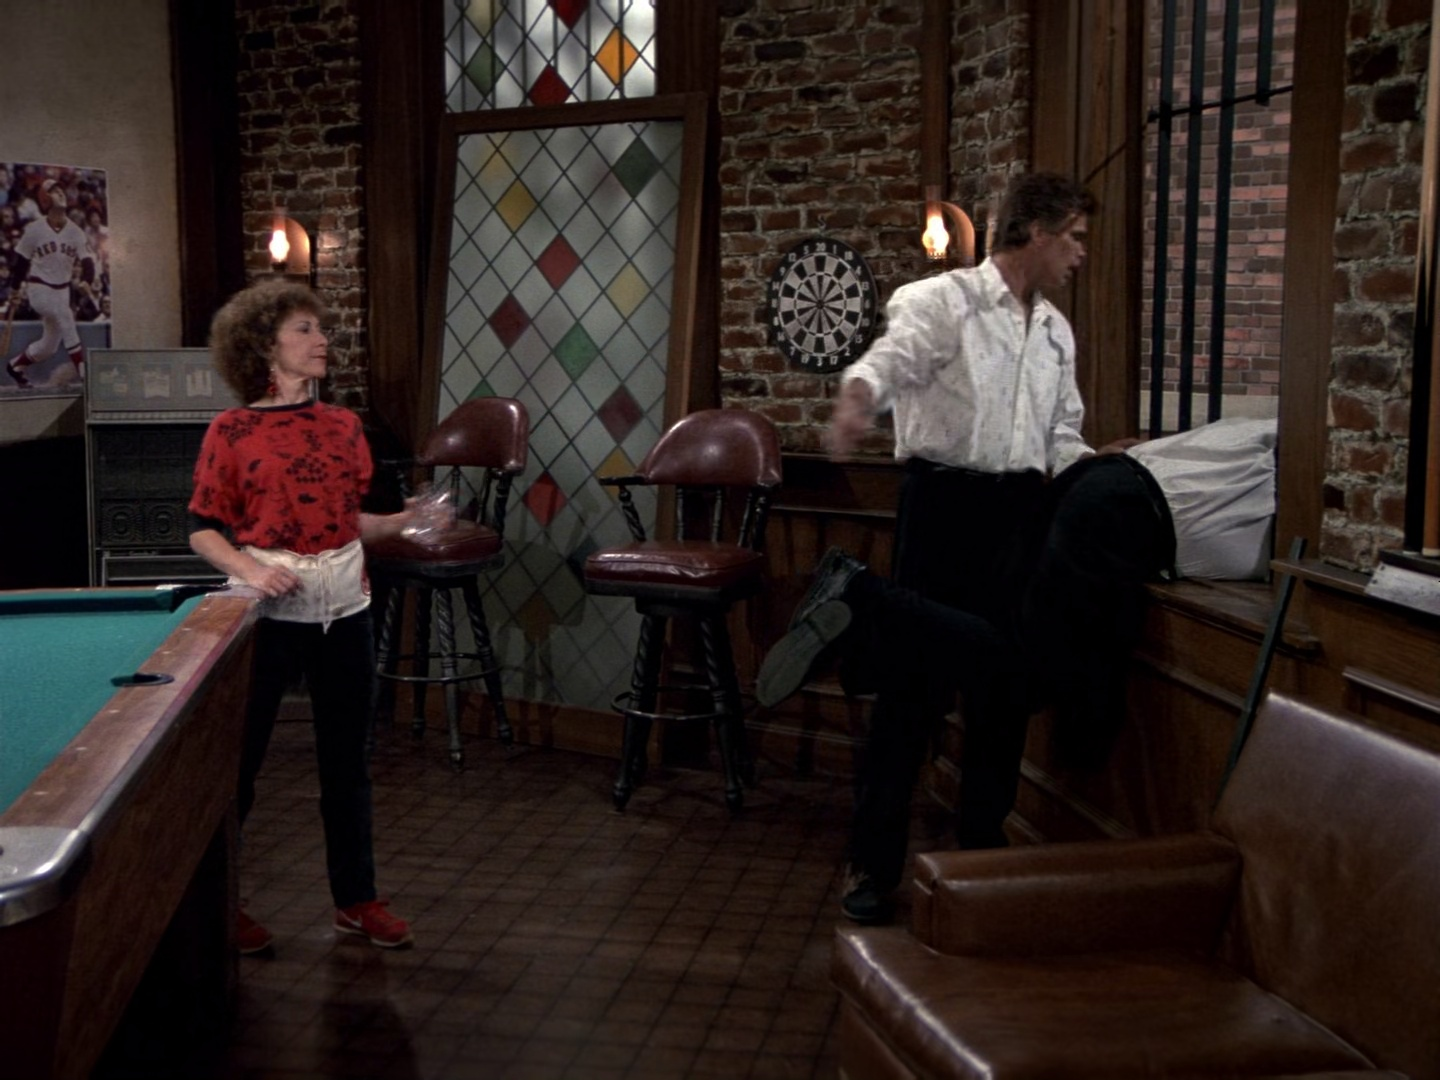

In [51]:
show_by_name(m[8])